# Tutorial 14 — Beam pattern × scene integration (W-band down-looking)

A radar does not sample its boresight pixel; it samples a
pattern-weighted integral over its solid angle. When the scene is
homogeneous, the closed-form $\sigma_\mathrm{beam}$ used in
Tutorial 13 captures everything. When the scene has structure on
scales comparable to (or finer than) the beam footprint — convective
cells, updraft/downdraft couplets, reflectivity gradients — that
closed form fails and the beam has to be integrated explicitly.

Two properties of the pattern matter independently:

* **Main-lobe width.** A 1° beam at 15 km range has a ≈ 260 m
  footprint; a 3° beam has ≈ 780 m. Features narrower than the
  footprint are smeared.
* **Sidelobes.** A uniform circular aperture has an Airy first
  sidelobe at **−17.6 dB**. A distant bright cell sitting in that
  sidelobe can dominate the moments if the main lobe is pointed at a
  quiet patch.

This notebook uses the new `rustmatrix.spectra.beam` module. A
down-looking radar at 20 km altitude scans across a synthetic rain
scene: 20 dBZ Marshall-Palmer background with 500-m-wide 45 dBZ
cells spaced every 1.5 km. Each cell carries a co-located vertical
motion — three combinations are explored:

* **uniform_updraft** — every cell is a 3 m/s updraft.
* **alternating** — adjacent cells alternate −3 / +3 m/s.
* **dipole_couplet** — each cell is an updraft/downdraft dipole
  straddling the enhanced-Z peak.

Each scene is sampled with 1° and 3° beams, in both Gaussian and
Airy patterns. Horizontal wind is zero throughout — we isolate the
*scene-structure* contribution to beam broadening here; Tutorial 13
covered the uniform-wind case.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rustmatrix import Scatterer
from rustmatrix.psd import PSDIntegrator
from rustmatrix.refractive import m_w_10C
from rustmatrix.spectra import brandes_et_al_2002
from rustmatrix.spectra.beam import (AiryBeam, BeamIntegrator, GaussianBeam,
                                      Scene, marshall_palmer_psd_factory)
from rustmatrix.tmatrix_aux import (K_w_sqr, dsr_thurai_2007,
                                     geom_vert_back, wl_W)

RADAR_ALTITUDE_M = 20000.0
TARGET_ALTITUDE_M = 3000.0
RANGE_M = RADAR_ALTITUDE_M - TARGET_ALTITUDE_M
RAIN_TOP_M = 5000.0

BG_DBZ = 20.0
CELL_PEAK_DBZ = 45.0
CELL_WIDTH_M = 500.0
CELL_SIGMA_M = CELL_WIDTH_M / (2.0 * np.sqrt(2.0 * np.log(2.0)))
CELL_CENTERS_X = np.arange(-3000.0, 3001.0, 1500.0)
W_PEAK = 3.0

SCAN_X = np.linspace(-4000.0, 4000.0, 81)
V_MIN, V_MAX, N_BINS = -5.0, 15.0, 384


## Beam-pattern comparison
Before running the full scene sweep, look at the two candidate
patterns at identical HPBW. The Gaussian taper has no sidelobes;
the Airy pattern has nulls and a first sidelobe at −17.6 dB.


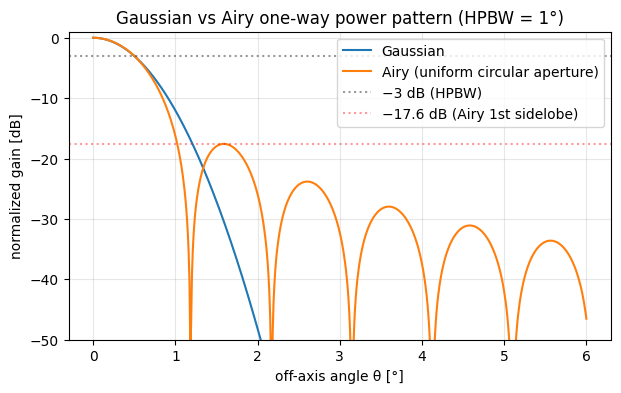

In [2]:
theta = np.linspace(0, np.deg2rad(6), 600)
gb = GaussianBeam(hpbw=np.deg2rad(1.0))
ab = AiryBeam(hpbw=np.deg2rad(1.0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.rad2deg(theta), 10 * np.log10(np.clip(gb.gain(theta), 1e-6, None)),
        label='Gaussian', lw=1.5)
ax.plot(np.rad2deg(theta), 10 * np.log10(np.clip(ab.gain(theta), 1e-6, None)),
        label='Airy (uniform circular aperture)', lw=1.5)
ax.axhline(-3, c='k', ls=':', alpha=0.4, label='−3 dB (HPBW)')
ax.axhline(-17.6, c='r', ls=':', alpha=0.4, label='−17.6 dB (Airy 1st sidelobe)')
ax.set_xlabel('off-axis angle θ [°]')
ax.set_ylabel('normalized gain [dB]')
ax.set_ylim(-50, 1)
ax.set_title('Gaussian vs Airy one-way power pattern (HPBW = 1°)')
ax.legend()
ax.grid(alpha=0.3);


## Build the scene
Each scene is a triple of callables `(Z_dBZ, w, u_h)` evaluated at
pixel positions. We bake in the rain top at 5 km (above that the
scene is empty), the cell grid, and the three vertical-motion
variants.


In [3]:
def make_scene(pattern):
    centers = CELL_CENTERS_X
    sigma = CELL_SIGMA_M
    z_top = RAIN_TOP_M
    Z_bg_lin = 10.0 ** (BG_DBZ / 10.0)
    Z_peak_excess = 10.0 ** (CELL_PEAK_DBZ / 10.0) - Z_bg_lin

    def Z_dBZ(x, y, z):
        mask = (z >= 0) & (z <= z_top)
        Z_lin = np.where(mask, Z_bg_lin, 1e-10)
        for xc in centers:
            bump = Z_peak_excess * np.exp(-0.5 * ((x - xc) / sigma) ** 2)
            Z_lin = Z_lin + bump * mask
        return 10.0 * np.log10(np.maximum(Z_lin, 1e-10))

    if pattern == 'uniform_updraft':
        signs = -np.ones(len(centers))
    elif pattern == 'alternating':
        signs = np.array([-1.0 if i % 2 == 0 else 1.0
                          for i in range(len(centers))])
    elif pattern == 'dipole_couplet':
        signs = None
    else:
        raise ValueError(pattern)

    def w_fn(x, y, z):
        mask = (z >= 0) & (z <= z_top)
        w_total = np.zeros_like(x)
        for i, xc in enumerate(centers):
            arg = (x - xc) / sigma
            if signs is None:
                w_total = w_total + W_PEAK * arg * np.exp(0.5 - 0.5 * arg ** 2)
            else:
                w_total = w_total + signs[i] * W_PEAK * np.exp(-0.5 * arg ** 2)
        return w_total * mask

    def u_h_fn(x, y, z):
        return np.zeros_like(x)

    return Scene(Z_dBZ=Z_dBZ, w=w_fn, u_h=u_h_fn, u_h_azimuth=0.0)


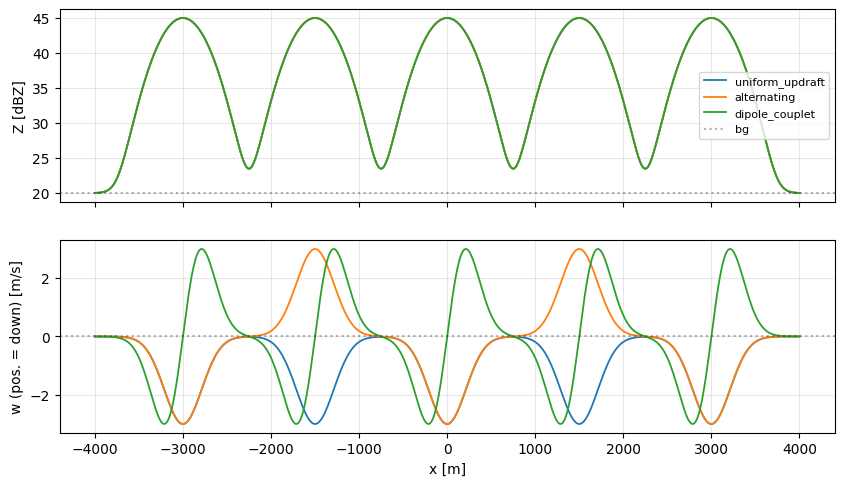

In [4]:
# Visualize each scene along the x-axis at z = TARGET_ALTITUDE_M.
x_vis = np.linspace(-4000, 4000, 801)
zero = np.zeros_like(x_vis)
z_target = np.full_like(x_vis, TARGET_ALTITUDE_M)

fig, (axZ, axW) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for name in ('uniform_updraft', 'alternating', 'dipole_couplet'):
    sc = make_scene(name)
    axZ.plot(x_vis, sc.Z_dBZ(x_vis, zero, z_target), label=name, lw=1.3)
    axW.plot(x_vis, sc.w(x_vis, zero, z_target), label=name, lw=1.3)
axZ.set_ylabel('Z [dBZ]')
axZ.axhline(BG_DBZ, c='k', ls=':', alpha=0.3, label='bg')
axZ.legend(fontsize=8)
axZ.grid(alpha=0.3)
axW.set_xlabel('x [m]')
axW.set_ylabel('w (pos. = down) [m/s]')
axW.axhline(0, c='k', ls=':', alpha=0.3)
axW.grid(alpha=0.3);


## W-band rain scatterer and the scan sweep
The `BeamIntegrator` takes the scatterer, beam pattern, scene, and
a PSD factory (Z → PSD mapping — Marshall–Palmer here) and returns
a `SpectralResult` identical to the one produced by the ordinary
`SpectralIntegrator`. We run it once per scan position.


In [5]:
rain = Scatterer(wavelength=wl_W, m=m_w_10C[wl_W],
                 Kw_sqr=K_w_sqr[wl_W], ddelt=1e-4, ndgs=2)
integ = PSDIntegrator()
integ.D_max = 5.0
integ.num_points = 48
integ.axis_ratio_func = lambda D: 1.0 / dsr_thurai_2007(D)
integ.geometries = (geom_vert_back,)
rain.psd_integrator = integ
rain.psd_integrator.init_scatter_table(rain)

psd_factory = marshall_palmer_psd_factory(N0=8000.0, D_max=5.0)


In [6]:
def moments(v, sZh):
    sZh = np.clip(sZh, 0.0, None)
    P = sZh.sum()
    if P <= 0:
        return -np.inf, np.nan, np.nan
    dv = np.mean(np.diff(v))
    Z_dBZ = 10.0 * np.log10(max(P * dv, 1e-10))
    mu = float((v * sZh).sum() / P)
    var = float(((v - mu) ** 2 * sZh).sum() / P)
    return Z_dBZ, mu, float(np.sqrt(max(var, 0.0)))

def sweep(scene, beam):
    Zs = np.empty_like(SCAN_X)
    mus = np.empty_like(SCAN_X)
    sigs = np.empty_like(SCAN_X)
    for i, xr in enumerate(SCAN_X):
        bi = BeamIntegrator(
            scatterer=rain, beam=beam, scene=scene,
            psd_factory=psd_factory, fall_speed=brandes_et_al_2002,
            radar_position=(xr, 0.0, RADAR_ALTITUDE_M),
            boresight=(0.0, 0.0, -1.0), range_m=RANGE_M,
            v_min=V_MIN, v_max=V_MAX, n_bins=N_BINS,
            n_theta=16, n_phi=16,
        )
        r = bi.run()
        Zs[i], mus[i], sigs[i] = moments(r.v, r.sZ_h)
    return Zs, mus, sigs


In [7]:
PATTERNS = ('uniform_updraft', 'alternating', 'dipole_couplet')
BEAMS = (
    ('gaussian', 1.0, GaussianBeam(hpbw=np.deg2rad(1.0))),
    ('airy',     1.0, AiryBeam(hpbw=np.deg2rad(1.0))),
    ('gaussian', 3.0, GaussianBeam(hpbw=np.deg2rad(3.0))),
    ('airy',     3.0, AiryBeam(hpbw=np.deg2rad(3.0))),
)

results = {}
for pattern in PATTERNS:
    scene = make_scene(pattern)
    for kind, hpbw_deg, beam in BEAMS:
        results[(pattern, kind, hpbw_deg)] = sweep(scene, beam)
    print(f'  {pattern:18s}  done')


  uniform_updraft     done


  alternating         done


  dipole_couplet      done


## Scan curves — moments vs radar x position
For each scene, plot $Z$, $V_R$ (Doppler velocity, first moment),
and $\sigma$ (spectral width) as the radar sweeps across the cell
grid. Compare how narrow (1°) and wide (3°) beams resolve the
structure, and how the Airy sidelobes leak in neighbouring-cell
signal even when the main lobe is off a peak.


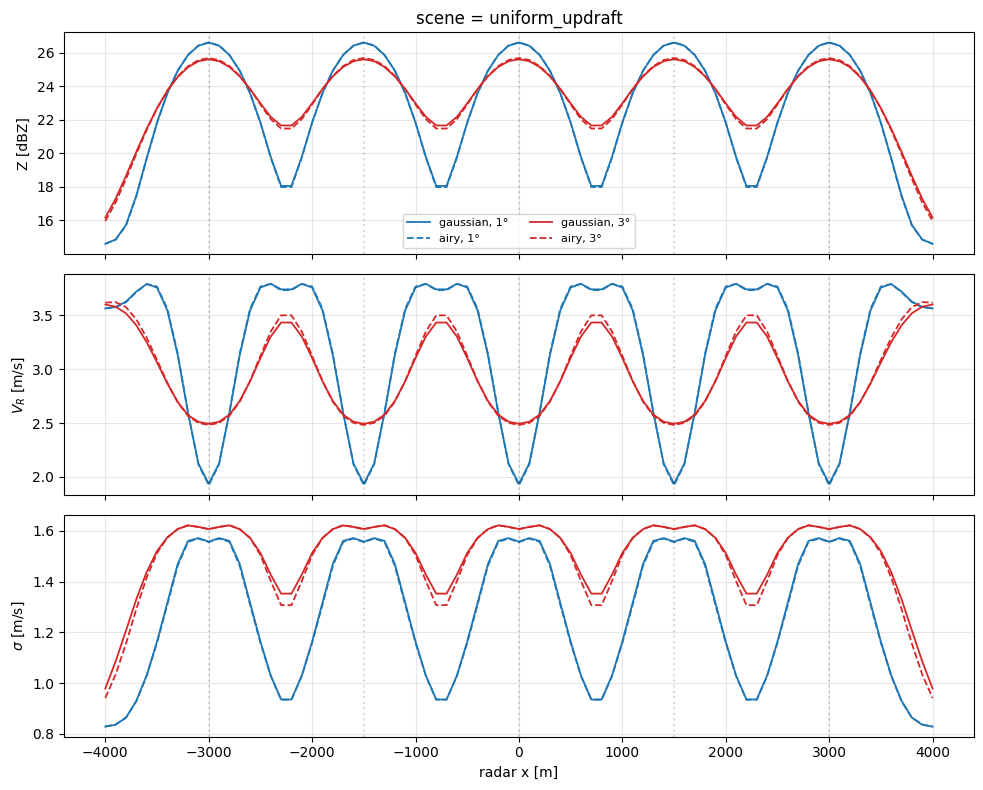

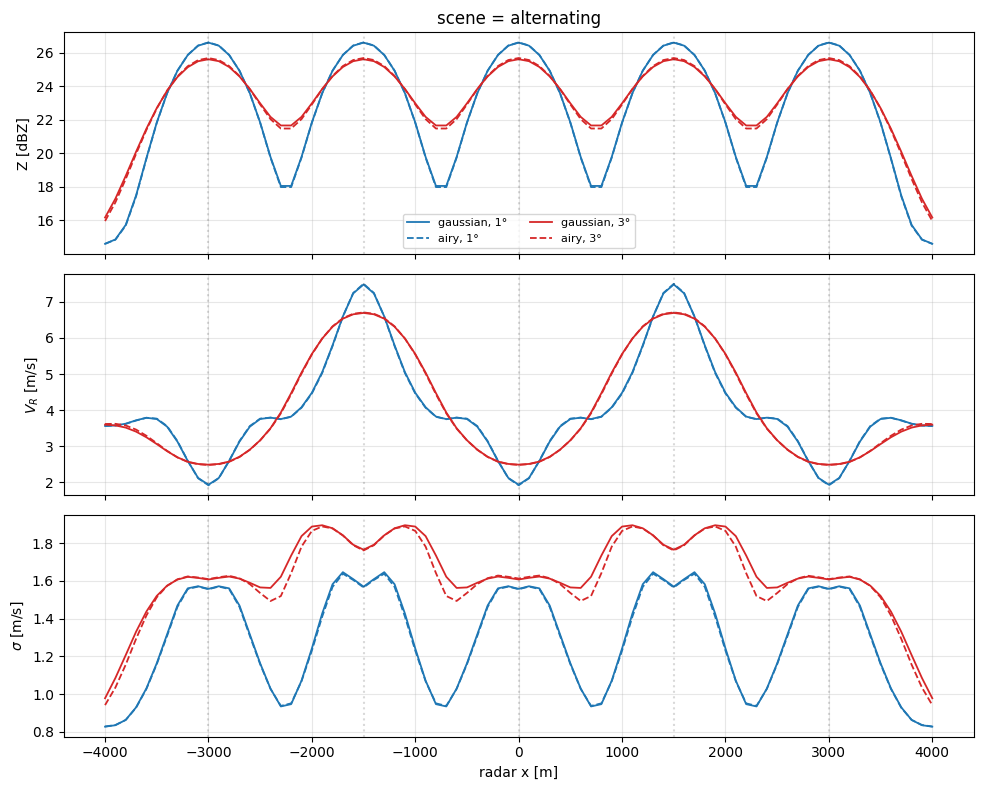

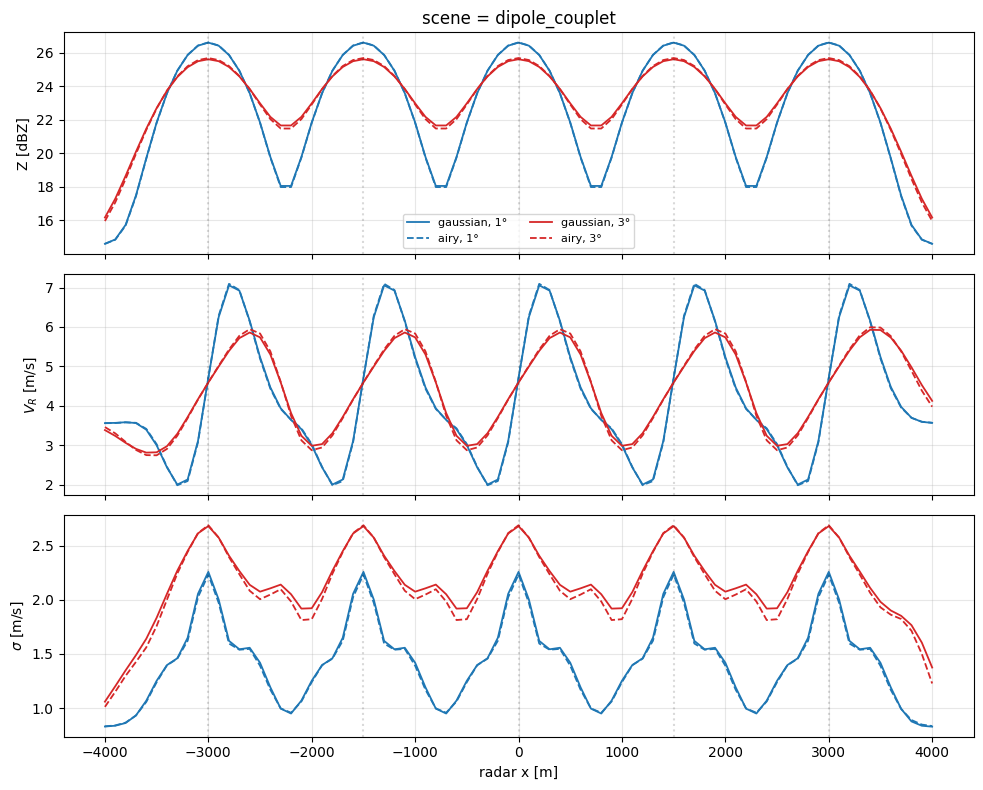

In [8]:
def plot_scan(pattern):
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    styles = {('gaussian', 1.0): ('tab:blue', '-'),
              ('airy',     1.0): ('tab:blue', '--'),
              ('gaussian', 3.0): ('tab:red', '-'),
              ('airy',     3.0): ('tab:red', '--')}
    for (kind, hpbw_deg), (c, ls) in styles.items():
        Zs, mus, sigs = results[(pattern, kind, hpbw_deg)]
        lbl = f'{kind}, {hpbw_deg:.0f}°'
        axes[0].plot(SCAN_X, Zs, c=c, ls=ls, lw=1.3, label=lbl)
        axes[1].plot(SCAN_X, mus, c=c, ls=ls, lw=1.3)
        axes[2].plot(SCAN_X, sigs, c=c, ls=ls, lw=1.3)
    # mark cell centers
    for xc in CELL_CENTERS_X:
        for ax in axes:
            ax.axvline(xc, c='k', ls=':', alpha=0.15)
    axes[0].set_ylabel('Z [dBZ]')
    axes[1].set_ylabel(r'$V_R$ [m/s]')
    axes[2].set_ylabel(r'$\sigma$ [m/s]')
    axes[2].set_xlabel('radar x [m]')
    axes[0].set_title(f'scene = {pattern}')
    axes[0].legend(fontsize=8, ncol=2)
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig

for p in PATTERNS:
    plot_scan(p);


## Interpretation
* **Narrow (1°) vs wide (3°) main lobes.** The 1° beam's ~260 m
  footprint is narrower than the 500 m cell, so $Z$ resolves the
  full peak-to-trough swing ($\approx$25 dB). The 3° beam averages
  across neighbouring cells and the peak-to-trough contrast drops
  to a few dB.
* **Gaussian vs Airy (same HPBW).** The main-lobe difference is
  small — both patterns integrate a similar main-lobe footprint of
  reflectivity. The *sidelobes* of the Airy pattern pick up signal
  from cells up to $\pm 2$ km away, leaking a small bias into the
  inter-cell minima. The `alternating` and `dipole_couplet` scenes
  show this most clearly: at the between-cell location, Airy's
  $V_R$ is shifted toward the nearer cell's velocity while Gaussian
  is closer to zero (the DSD-intrinsic rest frame).
* **uniform_updraft vs alternating.** Both start from the same Z
  field, but in `alternating` adjacent cells pull $V_R$ in opposite
  directions — when the 3° beam straddles a boundary it sees a
  bimodal spectrum whose first moment can land near zero even
  though both contributing populations are strongly non-still.
  This is the physical origin of the "turbulence" signature in
  spectral-width retrievals over convection.
* **dipole_couplet.** At the cell centre the beam averages equal
  up- and downdraft power, giving $V_R \approx v_t$ (DSD-only) and
  an inflated $\sigma$ — the classic bimodal-spectrum fingerprint.
  The 3° beam smooths over more of the couplet, narrowing the
  apparent $\sigma$ swing.
* **Practical take.** Any moment retrieval that assumes a pencil
  beam and homogeneous scene is subtracting the wrong amount of
  "beam broadening" from the observed $\sigma$. The
  `BeamIntegrator` lets you attach a forward model to a scene and
  an instrument specification, and returns spectra and moments
  that the observed radar actually would see.


## Interactive exploration — cell spacing
The sweep above used 1.5 km spacing between cells. What happens
when that spacing shrinks below the beam footprint, or grows to
where even a wide beam resolves the cells cleanly? The slider
below varies the spacing from **100 m** (far finer than either
beam footprint) to **10 km** (fully resolved by both). At fine
spacings the `alternating` pattern's $V_R$ collapses toward zero
— adjacent up- and downdrafts average inside the pattern — while
$\sigma$ balloons because the spectrum becomes bimodal. At coarse
spacings the 1° and 3° beams converge on the same answer because
both now resolve the scene.

This widget drives the same `BeamIntegrator` used above, but on a
coarser scan (41 x-positions, 10×10 beam samples) so each slider
change completes in a few seconds.


In [9]:
import ipywidgets as widgets

FAST_SCAN_X = np.linspace(-4000.0, 4000.0, 41)

def _scene_at_spacing(pattern, spacing_m):
    centers = np.arange(-4000.0, 4000.0 + 1e-6, spacing_m)
    sigma = CELL_SIGMA_M
    z_top = RAIN_TOP_M
    Z_bg_lin = 10.0 ** (BG_DBZ / 10.0)
    Z_peak_excess = 10.0 ** (CELL_PEAK_DBZ / 10.0) - Z_bg_lin

    def Z_dBZ(x, y, z):
        mask = (z >= 0) & (z <= z_top)
        Z_lin = np.where(mask, Z_bg_lin, 1e-10)
        for xc in centers:
            bump = Z_peak_excess * np.exp(-0.5 * ((x - xc) / sigma) ** 2)
            Z_lin = Z_lin + bump * mask
        return 10.0 * np.log10(np.maximum(Z_lin, 1e-10))

    if pattern == 'uniform_updraft':
        signs = -np.ones(len(centers))
    elif pattern == 'alternating':
        signs = np.array([-1.0 if i % 2 == 0 else 1.0
                          for i in range(len(centers))])
    elif pattern == 'dipole_couplet':
        signs = None
    else:
        raise ValueError(pattern)

    def w_fn(x, y, z):
        mask = (z >= 0) & (z <= z_top)
        w_total = np.zeros_like(x)
        for i, xc in enumerate(centers):
            arg = (x - xc) / sigma
            if signs is None:
                w_total = w_total + W_PEAK * arg * np.exp(0.5 - 0.5 * arg ** 2)
            else:
                w_total = w_total + signs[i] * W_PEAK * np.exp(-0.5 * arg ** 2)
        return w_total * mask

    def u_h_fn(x, y, z):
        return np.zeros_like(x)

    return Scene(Z_dBZ=Z_dBZ, w=w_fn, u_h=u_h_fn, u_h_azimuth=0.0), centers

def _fast_sweep(scene, beam):
    mus = np.empty_like(FAST_SCAN_X)
    sigs = np.empty_like(FAST_SCAN_X)
    for i, xr in enumerate(FAST_SCAN_X):
        bi = BeamIntegrator(
            scatterer=rain, beam=beam, scene=scene,
            psd_factory=psd_factory, fall_speed=brandes_et_al_2002,
            radar_position=(xr, 0.0, RADAR_ALTITUDE_M),
            boresight=(0.0, 0.0, -1.0), range_m=RANGE_M,
            v_min=V_MIN, v_max=V_MAX, n_bins=192,
            n_theta=10, n_phi=10,
        )
        r = bi.run()
        _, mus[i], sigs[i] = moments(r.v, r.sZ_h)
    return mus, sigs

def explore_spacing(spacing_m=1500.0, pattern='alternating'):
    scene, centers = _scene_at_spacing(pattern, spacing_m)
    g1 = GaussianBeam(hpbw=np.deg2rad(1.0))
    g3 = GaussianBeam(hpbw=np.deg2rad(3.0))
    mus1, sigs1 = _fast_sweep(scene, g1)
    mus3, sigs3 = _fast_sweep(scene, g3)

    x_vis = np.linspace(-4000, 4000, 801)
    zero = np.zeros_like(x_vis)
    z_target = np.full_like(x_vis, TARGET_ALTITUDE_M)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(x_vis, scene.Z_dBZ(x_vis, zero, z_target), 'k-', lw=1.0)
    axes[0].set_ylabel('Z [dBZ]')
    axes[1].plot(FAST_SCAN_X, mus1, color='tab:blue', lw=1.5, label='1° Gaussian')
    axes[1].plot(FAST_SCAN_X, mus3, color='tab:red',  lw=1.5, label='3° Gaussian')
    axes[1].set_ylabel(r'$V_R$ [m/s]')
    axes[1].legend(fontsize=8, loc='best')
    axes[2].plot(FAST_SCAN_X, sigs1, color='tab:blue', lw=1.5)
    axes[2].plot(FAST_SCAN_X, sigs3, color='tab:red',  lw=1.5)
    axes[2].set_ylabel(r'$\sigma$ [m/s]')
    axes[2].set_xlabel('radar x [m]')
    for xc in centers:
        for ax in axes:
            ax.axvline(xc, color='k', ls=':', alpha=0.12)
    for ax in axes:
        ax.grid(alpha=0.3)
    axes[0].set_title(f'pattern = {pattern},  spacing = {spacing_m:.0f} m,  '
                      f'{len(centers)} cells')
    fig.tight_layout()
    plt.show()

spacing_slider = widgets.FloatLogSlider(
    value=1500.0, base=10,
    min=np.log10(100.0), max=np.log10(10000.0),
    step=0.02, description='spacing [m]',
    readout_format='.0f', continuous_update=False,
)
pattern_dd = widgets.Dropdown(
    options=['uniform_updraft', 'alternating', 'dipole_couplet'],
    value='alternating', description='pattern',
)
widgets.interact(explore_spacing, spacing_m=spacing_slider, pattern=pattern_dd);


interactive(children=(FloatLogSlider(value=1500.0, continuous_update=False, description='spacing [m]', min=2.0…